In [ ]:
!pip show sentence_transformers

Name: sentence-transformers
Version: 5.2.2
Summary: Embeddings, Retrieval, and Reranking
Home-page: https://www.SBERT.net
Author: 
Author-email: Nils Reimers <info@nils-reimers.de>, Tom Aarsen <tom.aarsen@huggingface.co>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface-hub, numpy, scikit-learn, scipy, torch, tqdm, transformers, typing_extensions
Required-by: 


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from datasets import load_dataset

# Load the labeled subset (most common)
dataset = load_dataset('keivalya/MedQuad-MedicalQnADataset')

print(dataset)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

qtype_counts = pd.Series(dataset['train']['qtype']).value_counts()

plt.figure(figsize=(10, 6))
qtype_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Add labels and title
plt.title('Distribution of Samples per qtype', fontsize=15)
plt.xlabel('Category (qtype)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('qtype_distribution.png')
plt.show()

# Optional: Print the exact numbers
print("Sample counts per category:")
print(qtype_counts)

In [ ]:
small_dataset = dataset['train'].shuffle(seed=42).select(range(7000))



In [ ]:
small_dataset = small_dataset.rename_column("Question", "question")
small_dataset = small_dataset.rename_column("Answer", "answer")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

qtype_counts = pd.Series(small_dataset['qtype']).value_counts()

plt.figure(figsize=(10, 6))
qtype_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Add labels and title
plt.title('Distribution of Samples per qtype', fontsize=15)
plt.xlabel('Category (qtype)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('qtype_distribution.png')
plt.show()

# Optional: Print the exact numbers
print("Sample counts per category:")
print(qtype_counts)

In [ ]:
small_dataset=small_dataset.remove_columns(['qtype'])

In [ ]:
from datasets import Dataset
import pandas as pd
from datasets import concatenate_datasets


In [ ]:

file_path = '/content/gdrive/MyDrive/Training_QA_dataset.csv'
df = pd.read_csv(file_path)

print(f"Successfully loaded {len(df)} rows and {len(df.columns)} columns from {file_path}")

In [ ]:
data=Dataset.from_pandas(df)

In [ ]:
data

In [ ]:

fine_tuning_data=concatenate_datasets([small_dataset,data])

In [ ]:
fine_tuning_data

In [ ]:
import os
save_path = "/content/gdrive/MyDrive/Med_qa"

os.makedirs(save_path, exist_ok=True)
fine_tuning_data.save_to_disk(save_path)

print(f"Dataset successfully saved to: {save_path}")

In [ ]:
fine_tuning_data

The data collection and combining process has been completed.

Working on toy dataset.

In [ ]:
toy_data = {
    "questions": [
        "What are the common symptoms of a meningioma?",
        "How is a brain tumor typically diagnosed?",
        "What is the difference between benign and malignant tumors?",
        "What is a glioma?",
        "What are the treatment options for localized meningiomas?",
        "Can radiation therapy be used for brain tumors?",
        "What is the role of the blood-brain barrier in treatment?",
        "What is an acoustic neuroma?"
    ],
    "answers": [
        "Common symptoms include headaches, vision changes, hearing loss, and seizures caused by pressure on the brain.",
        "Diagnosis usually involves neurological exams followed by imaging tests like MRI or CT scans, and sometimes a biopsy.",
        "Benign tumors are non-cancerous and grow slowly, while malignant tumors are cancerous, aggressive, and can invade nearby tissue.",
        "A glioma is a type of tumor that starts in the glial cells, which are the supportive cells that surround nerve cells in the brain.",
        "Primary treatments include surgical resection to remove the tumor or stereotactic radiosurgery if the tumor is hard to reach.",
        "Yes, radiation uses high-energy beams to kill tumor cells and is often used after surgery to destroy any remaining fragments.",
        "The blood-brain barrier protects the brain from toxins but can also block many chemotherapy drugs from reaching tumor cells.",
        "An acoustic neuroma is a noncancerous tumor on the main nerve leading from the inner ear to the brain."
    ]
}

Trial Done.

In [ ]:
from datasets import Dataset,load_from_disk


In [ ]:
dataset=load_from_disk('/content/gdrive/MyDrive/Med_qa')

In [ ]:
dataset

In [ ]:
work_dataset=dataset.train_test_split(test_size=0.20,seed=42)
print(work_dataset)

In [ ]:
from datasets import DatasetDict

In [ ]:

temp_split = work_dataset['test'].train_test_split(test_size=0.5, seed=42)


work_dataset = DatasetDict({
    'train': work_dataset['train'],
    'validation': temp_split['train'],
    'test': temp_split['test']
})



In [ ]:
import os
save_path = "/content/gdrive/My Drive/qa_train_test_val_data"

os.makedirs(save_path, exist_ok=True)

work_dataset.save_to_disk(save_path)

print(f"Dataset successfully saved to: {save_path}")

Start training part from here.

In [ ]:
work_dataset=load_from_disk('/content/gdrive/MyDrive/qa_train_test_val_data')

In [ ]:
work_dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 6460
    })
    validation: Dataset({
        features: ['question', 'answer'],
        num_rows: 808
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 808
    })
})

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

Using device: cuda


In [ ]:
from datasets import Dataset
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, losses, SentenceTransformerTrainingArguments


model=SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

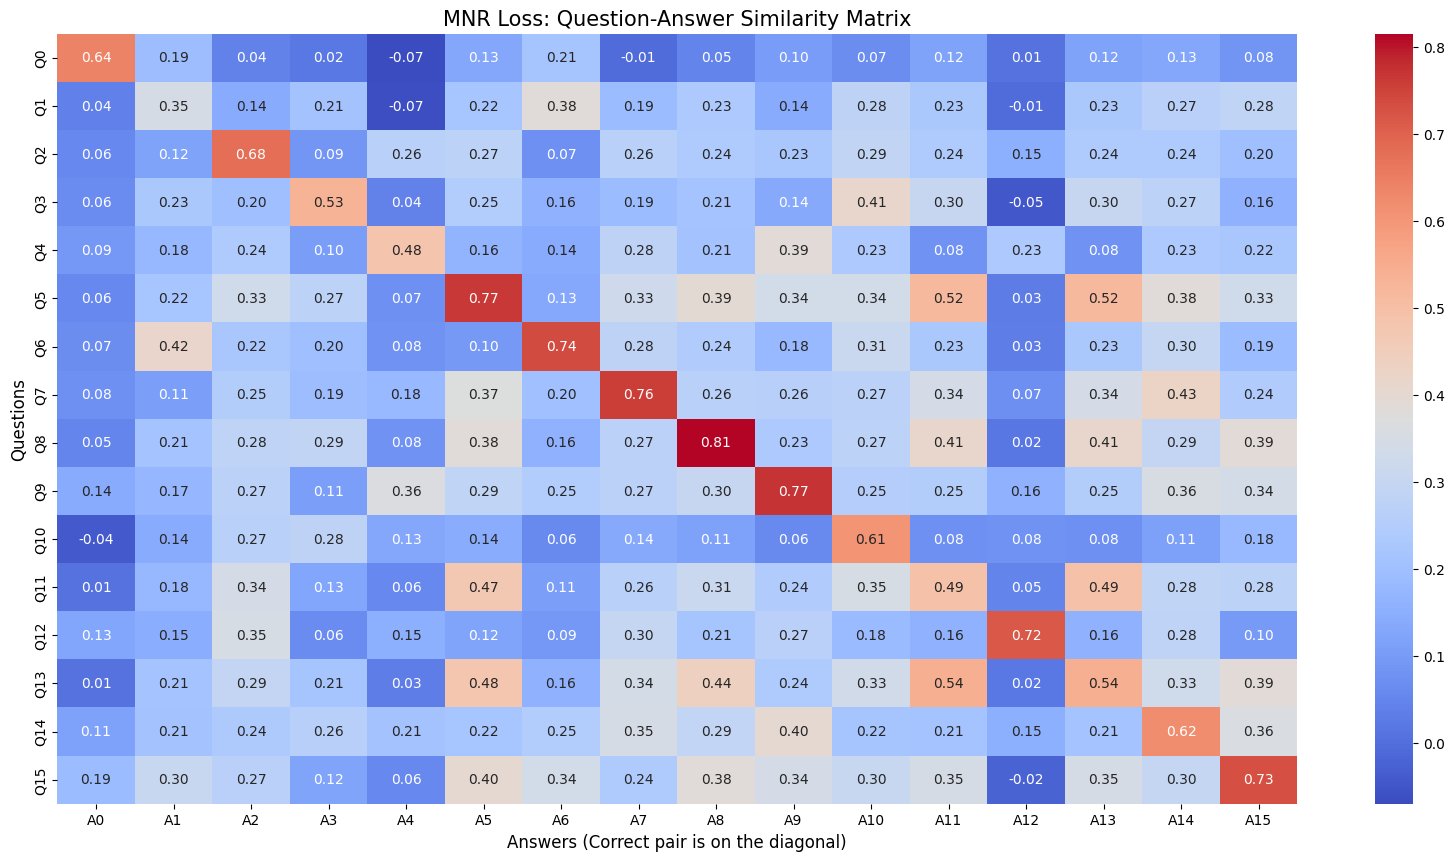

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util



# 2. Select a random batch of samples (e.g., 8 samples for clear visualization)
batch_size = 16
random_indices = torch.randint(0, len(work_dataset['test']), (batch_size,)).tolist()
batch = [work_dataset['test'][i] for i in random_indices]

# 3. Extract questions and answers
questions = [item['question'] for item in batch]
answers = [item['answer'] for item in batch]

# 4. Generate Embeddings
q_embeddings = model.encode(questions, convert_to_tensor=True)
a_embeddings = model.encode(answers, convert_to_tensor=True)

sim_matrix = util.cos_sim(q_embeddings, a_embeddings).cpu().numpy()

# 6. Plot the Heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(
    sim_matrix,
    annot=True,          # Show the similarity score in each cell
    fmt=".2f",
    cmap="coolwarm",       # Darker colors for higher similarity
    xticklabels=[f"A{i}" for i in range(batch_size)],
    yticklabels=[f"Q{i}" for i in range(batch_size)]
)

plt.title("MNR Loss: Question-Answer Similarity Matrix", fontsize=15)
plt.xlabel("Answers (Correct pair is on the diagonal)", fontsize=12)
plt.ylabel("Questions", fontsize=12)
plt.show()

It seems to be good lets enhance its performance by fine tuning.

In [ ]:
from sentence_transformers import InputExample

In [ ]:
train_examples = []
for item in work_dataset['train']:
    train_examples.append(
        InputExample(texts=[item['question'], item['answer']])
    )

In [ ]:
len(train_examples)

In [ ]:
from sentence_transformers.evaluation import InformationRetrievalEvaluator

In [ ]:
queries={}
corpus={}
relevant_docs={}

In [ ]:
queries = {str(i): work_dataset['validation']['question'][i]
           for i in range(len(work_dataset['validation']))}

corpus = {str(i): work_dataset['validation']['answer'][i]
          for i in range(len(work_dataset['validation']))}

relevant_docs = {str(i): {str(i)}
                 for i in range(len(work_dataset['validation']))}

In [ ]:
evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="retriever_evaluator",
    main_score_function="cosine"
)

In [ ]:
train_loss = losses.MultipleNegativesRankingLoss(model)

In [ ]:
output_dir="./mini-lm-v2-fine-tune-5"

In [ ]:
from sentence_transformers.training_args import SentenceTransformerTrainingArguments, BatchSamplers

In [ ]:
training_args = SentenceTransformerTrainingArguments(
    output_dir=output_dir,
    learning_rate=5e-6,
    weight_decay=0.01,
    num_train_epochs=6,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    save_steps=100,
    logging_steps=10,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    max_grad_norm=1.0,
    lr_scheduler_type="linear",
    metric_for_best_model="retriever_evaluator_cosine_ndcg@10",
    greater_is_better=True,


    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    push_to_hub=False,
    report_to="wandb",
    run_name="mini-lm-fine-tune-5"
)

In [ ]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=work_dataset['train'].select_columns(['question', 'answer']),
    loss=train_loss,
    evaluator=evaluator
)

In [ ]:
checkpoint_path = "/content/mini-lm-v2-fine-tune-5/checkpoint-404"


In [ ]:
trainer.train(resume_from_checkpoint=checkpoint_path)

Step,Training Loss,Validation Loss,Retriever Evaluator Cosine Accuracy@1,Retriever Evaluator Cosine Accuracy@3,Retriever Evaluator Cosine Accuracy@5,Retriever Evaluator Cosine Accuracy@10,Retriever Evaluator Cosine Precision@1,Retriever Evaluator Cosine Precision@3,Retriever Evaluator Cosine Precision@5,Retriever Evaluator Cosine Precision@10,Retriever Evaluator Cosine Recall@1,Retriever Evaluator Cosine Recall@3,Retriever Evaluator Cosine Recall@5,Retriever Evaluator Cosine Recall@10,Retriever Evaluator Cosine Ndcg@10,Retriever Evaluator Cosine Mrr@10,Retriever Evaluator Cosine Map@100
500,0.079300,No log,0.824257,0.903465,0.922030,0.956683,0.824257,0.301155,0.184406,0.095668,0.824257,0.903465,0.922030,0.956683,0.890720,0.869668,0.871998
600,0.088300,No log,0.823020,0.902228,0.917079,0.954208,0.823020,0.300743,0.183416,0.095421,0.823020,0.902228,0.917079,0.954208,0.888983,0.868191,0.870780


TrainOutput(global_step=606, training_loss=0.03201505463115453, metrics={'train_runtime': 147.8845, 'train_samples_per_second': 262.096, 'train_steps_per_second': 4.098, 'total_flos': 0.0, 'train_loss': 0.03201505463115453, 'epoch': 6.0})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
best_checkpoint = trainer.state.best_model_checkpoint
print(f"The best model was found at: {best_checkpoint}")

The best model was found at: ./mini-lm-v2-fine-tune-5/checkpoint-500


In [ ]:

drive_path = "/content/drive/MyDrive/mini-lm-best-model"

trainer.save_model(drive_path)

print(f"Success! Your best model (from checkpoint-500) is now saved at: {drive_path}")

Success! Your best model (from checkpoint-500) is now saved at: /content/drive/MyDrive/mini-lm-best-model


In [ ]:
<stop>

In [ ]:
import wandb
wandb.finish()

eval/retriever_evaluator_cosine_accuracy@1,▁▆█▇██
eval/retriever_evaluator_cosine_accuracy@10,▁▂▅▇█▇
eval/retriever_evaluator_cosine_accuracy@3,▁▅▇▇█▇
eval/retriever_evaluator_cosine_accuracy@5,▁▅▇▆█▃
eval/retriever_evaluator_cosine_map@100,▁▅▇▇█▇
eval/retriever_evaluator_cosine_mrr@10,▁▅▇▇█▇
eval/retriever_evaluator_cosine_ndcg@10,▁▄▆▇█▇
eval/retriever_evaluator_cosine_precision@1,▁▆█▇██
eval/retriever_evaluator_cosine_precision@10,▁▂▄▇█▇
eval/retriever_evaluator_cosine_precision@3,▁▅▇▇█▇
+13,...


In [ ]:
from datasets import Dataset
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, losses, SentenceTransformerTrainingArguments


base_model=SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
base_model.to(device)

SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [ ]:
from sentence_transformers import SentenceTransformer

test_model = SentenceTransformer('/content/drive/MyDrive/mini-lm-best-model')
test_model.to(device)
print("Model loaded successfully from Drive!")

Model loaded successfully from Drive!


In [ ]:
queries={}
corpus={}
relevant_docs={}

In [ ]:
queries = {str(i): work_dataset['test']['question'][i]
           for i in range(len(work_dataset['test']))}

corpus = {str(i): work_dataset['test']['answer'][i]
          for i in range(len(work_dataset['test']))}

relevant_docs = {str(i): {str(i)}
                 for i in range(len(work_dataset['test']))}

In [ ]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import util

# 1. Select the same 16 samples for both models
batch_size = 16
random_indices = torch.randint(0, len(work_dataset['test']), (batch_size,)).tolist()
batch = [work_dataset['test'][i] for i in random_indices]

questions = [item['question'] for item in batch]
answers = [item['answer'] for item in batch]

# 2. Generate Embeddings for BASE MODEL
q_emb_base = base_model.encode(questions, convert_to_tensor=True)
a_emb_base = base_model.encode(answers, convert_to_tensor=True)
sim_base = util.cos_sim(q_emb_base, a_emb_base).cpu().numpy()

# 3. Generate Embeddings for TRAINED (TEST) MODEL
q_emb_test = test_model.encode(questions, convert_to_tensor=True)
a_emb_test = test_model.encode(answers, convert_to_tensor=True)
sim_test = util.cos_sim(q_emb_test, a_emb_test).cpu().numpy()

# 4. Plot Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot Base Model Heatmap
sns.heatmap(sim_base, annot=True, fmt=".2f", cmap="coolwarm", ax=ax1,
            xticklabels=[f"A{i}" for i in range(batch_size)],
            yticklabels=[f"Q{i}" for i in range(batch_size)])
ax1.set_title(f"Base Model Similarity\n(Pre-trained)", fontsize=16)
ax1.set_xlabel("Answers", fontsize=12)
ax1.set_ylabel("Questions", fontsize=12)

# Plot Trained Model Heatmap
sns.heatmap(sim_test, annot=True, fmt=".2f", cmap="coolwarm", ax=ax2,
            xticklabels=[f"A{i}" for i in range(batch_size)],
            yticklabels=[f"Q{i}" for i in range(batch_size)])
ax2.set_title(f"Trained Model Similarity\n(Fine-tuned Checkpoint-500)", fontsize=16)
ax2.set_xlabel("Answers", fontsize=12)
ax2.set_ylabel("Questions", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, losses, SentenceTransformerTrainingArguments

In [ ]:
test_model=SentenceTransformer("Gaykar/all-MiniLM-L6-medical-rag")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]